# Sign Language Digit Classification: VGG16 Transfer Learning
> **Project Goal:** To improve the accuracy of sign language digit recognition using VGG16 Transfer Learning.

### 1. Import Libraries
we import **TensorFlow** and other helper libraries for model building, data manipulation and visualization. We specifically use the pre-trained **VGG16** model as our feature extractor.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.vgg16 import preprocess_input

from google.colab import drive
drive.mount('/content/drive')
base_dir = '/content/drive/MyDrive/data'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

Mounted at /content/drive


### 2. Data Loading & Preprocessing
Using `image_dataset_from_directory`, we load our sign language images. We also apply .prefetch() to optimize training performance by allowing the CPU to prepare data while the GPU is training.

In [ ]:
# Label definitions for the 10 sign language digits
class_names = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

# Load datasets
class_names = ['1', '2', '3', '4', '5', '6', '7', '8', '9','10']

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=32, image_size=(224, 224), class_names=class_names
)
valid_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, shuffle=True, batch_size=32, image_size=(224, 224), class_names=class_names
)
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, shuffle=True, batch_size=32, image_size=(224, 224), class_names=class_names
)

print(f"Corrected Classes: {train_dataset.class_names}")

# Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

Found 559 files belonging to 10 classes.
Found 149 files belonging to 10 classes.
Found 329 files belonging to 10 classes.
Corrected Classes: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']


### 3. Exploratory Data Analysis (EDA)
Visualizing a sample of the training data ensures that the labels are correctly mapped and the images are loaded as expected.

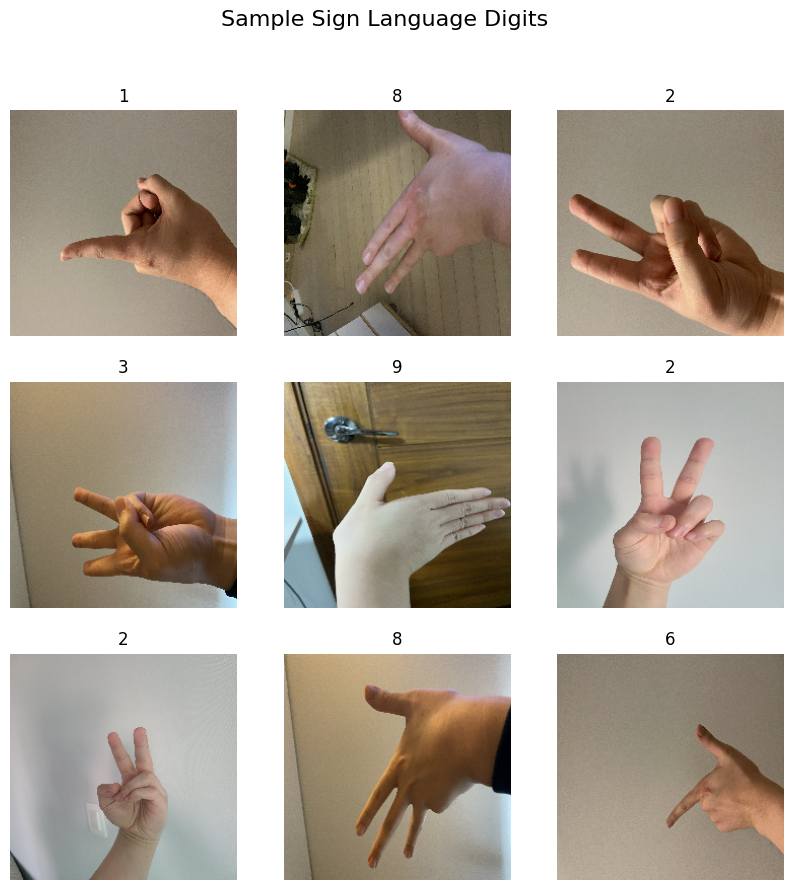

In [ ]:
# Visualization
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Sample Sign Language Digits", fontsize=16)
plt.show()

### 4. Data Augmentation & Preprocessing
To prevent overfitting on our small dataset, we implement **Data Augmentation**. We also apply **VGG16-specific preprocessing** via a Lambda layer to align our data with the ImageNet distribution.

In [ ]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(0.1),
])

def vgg_preprocess(x):
    return tf.keras.applications.vgg16.preprocess_input(x)

### 5. Build Transfer Learning Model
We implement **Transfer Learning** by leveraging a pre-trained **VGG16** base with frozen weights. To optimize for our task, we added a custom classification head featuring:
* **Global Average Pooling**: Effectively reduces total parameters and the risk of overfitting.
* **Dropout**: Provides additional regularization to improve generalization.

For the Transfer Learning model, we explicitly instantiate the **Adam optimizer** to gain finer control over the **learning rate**. This is crucial when fine-tuning pre-trained models to ensure stable convergence without disrupting the pre-learned features.

In [ ]:
# Build Model
base_model = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(vgg_preprocess, name='vgg_preprocessing'),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_preprocessing (Lambda)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,114,314 (57.66 MB)

 Trainable params: 398,090 (1.52 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

### 6. Training Model with Callbacks (Two-Phase Strategy)

To achieve optimal performance and prevent model degradation, we implement a **Two-Phase Training Strategy** using the following automated callbacks:

* **Phase 1: Feature Extraction** We initially train only the top classification layers (the "head") while keeping the VGG16 base frozen. This stabilizes the new weights without destroying the pre-trained ImageNet features.
    
* **Phase 2: Fine-tuning** Once the top layers are stable, we unfreeze the final convolutional blocks and retrain with a significantly lower learning rate ($10^{-5}$). This allows the model to adapt high-level visual patterns specifically to hand-sign nuances.

* **EarlyStopping** Monitors `validation loss` and automatically terminates the session if performance plateaus for 5 consecutive epochs, effectively preventing **overfitting**.

* **ModelCheckpoint** Ensures that only the **best-performing iteration** (the one with the lowest validation loss) is saved, protecting against performance fluctuations during the final epochs.

In [ ]:
# Phase 1: Training the Top Layers (Feature Extraction)

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_sign_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Starting Phase 1: Training the classification head...")
history = model.fit(
    train_dataset,
    epochs=25, # Initial training phase
    validation_data=valid_dataset,
    callbacks=callbacks
)

# Phase 2: Fine-Tuning (Deep Layer Optimization)

# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except for the last convolutional block (Block 5)
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Re-compile the model with a much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nStarting Phase 2: Fine-tuning the top convolutional blocks...")
# Resume training from the last epoch of the previous session
history_fine = model.fit(
    train_dataset,
    epochs=50, # Total epochs including the previous phase
    initial_epoch=history.epoch[-1],
    validation_data=valid_dataset,
    callbacks=callbacks
)

Starting Phase 1: Training the classification head...
Epoch 1/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2132 - loss: 2.7392
Epoch 1: val_loss improved from None to 2.79548, saving model to best_sign_model.keras

Epoch 1: finished saving model to best_sign_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 130s 7s/step - accuracy: 0.2826 - loss: 2.4452 - val_accuracy: 0.1812 - val_loss: 2.7955
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5255 - loss: 1.4816
Epoch 2: val_loss improved from 2.79548 to 2.73660, saving model to best_sign_model.keras

Epoch 2: finished saving model to best_sign_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.5349 - loss: 1.4293 - val_accuracy: 0.2013 - val_loss: 2.7366
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6232 - loss: 1.1117
Epoch 3: val_loss improved from 2.73660 to 2.19892, saving model to best_sign_model.keras

Epoch 3: finished saving model to best_sign_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 4

### 7. Model Evaluation & Visualization (Two-Phase Analysis)
We evaluate the optimal model—selected via `ModelCheckpoint`—against the unseen test dataset. To gain a comprehensive view of the training process, we visualize the integrated accuracy and loss curves, highlighting the transition from **Feature Extraction (Phase 1)** to **Fine-tuning (Phase 2)**. This allows us to verify the model's convergence and its ability to generalize across hand-sign variations.

11/11 ━━━━━━━━━━━━━━━━━━━━ 55s 5s/step - accuracy: 0.6687 - loss: 0.9840

[FINAL RESULT] Test Accuracy: 0.6687


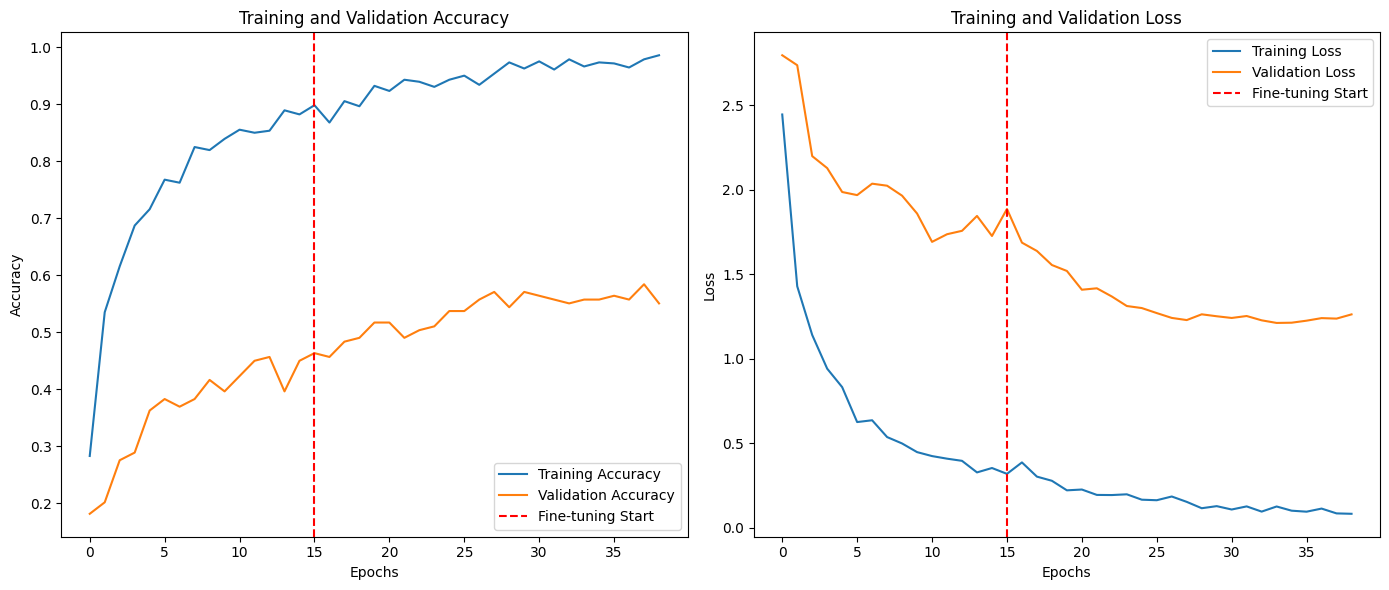

In [ ]:
# Load the best model saved by ModelCheckpoint
best_model = tf.keras.models.load_model(
    'best_sign_model.keras',
    custom_objects={'vgg_preprocess': vgg_preprocess}
)

# Perform evaluation
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"\n[FINAL RESULT] Test Accuracy: {test_acc:.4f}")

# Combine history from Phase 1 and Phase 2 for a complete view
total_acc = history.history['accuracy'] + history_fine.history['accuracy']
total_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
total_loss = history.history['loss'] + history_fine.history['loss']
total_val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Create an epoch range for the combined history
epochs_range = range(len(total_acc))

# Plot the Learning Curves
plt.figure(figsize=(14, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, total_acc, label='Training Accuracy')
plt.plot(epochs_range, total_val_acc, label='Validation Accuracy')
# Add a vertical line to indicate where Fine-tuning started
plt.axvline(x=len(history.history['accuracy'])-1, color='r', linestyle='--', label='Fine-tuning Start')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, total_loss, label='Training Loss')
plt.plot(epochs_range, total_val_loss, label='Validation Loss')
plt.axvline(x=len(history.history['accuracy'])-1, color='r', linestyle='--', label='Fine-tuning Start')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 8. Conclusion & Refective Summary
Through this project, I established a robust pipeline for sign language digit classification, achieving a **3x performance increase** (from 22% to 66% accuracy) by transitioning from a custom CNN to a Transfer Learning approach.

### **Key Insights:**
* **Effectiveness of Transfer Learning**: Utilizing pre-trained weights from VGG16 is highly effective for feature extraction, even when the target dataset is significantly smaller than the source (ImageNet).
* **Data Scarcity Challenges**: With approximately 1,000 images, the model reached a performance plateau at 66%. This suggests that for more complex tasks like sign language, a larger and more diverse dataset is essential to achieve 90%+ accuracy.
* **Regularization Impact**: Implementing **Dropout** and **Global Average Pooling** was critical in managing overfitting and ensuring the model generalized better to the validation and test sets.

---

### **Project Background**
This project was initially developed as a mid-term assignment for the **Department of AI at Korea National Open University (KNOU)** in April 2025. It serves as a foundational study on applying Deep Learning architectures to practical computer vision tasks.